<a href="https://colab.research.google.com/github/Dharshini11042004/Building_Information_System_-VIT_Vellore-/blob/main/Building_Information_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter the building name: Silver Jubliee Tower
Enter the date (YYYY-MM-DD) or range (YYYY-MM-DD to YYYY-MM-DD): 2025-01-01 to 2025-04-17

Electricity: 312012 kWh
Water: 107000 L
Solar: 32100 kWh
Recycled: 214000 L
Season: Winter, Weekend: No


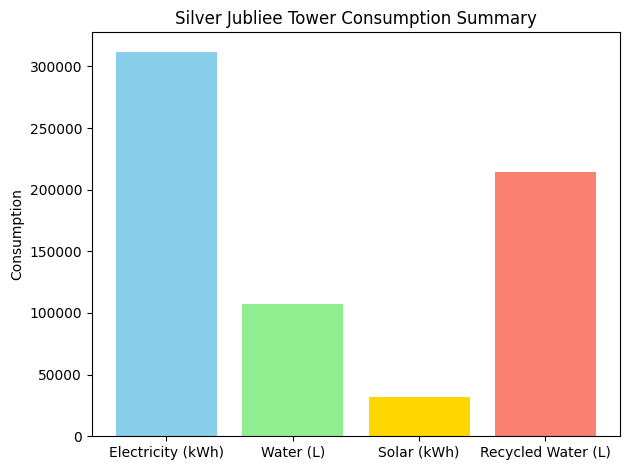

In [ ]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

# Sample dataset
building_data = [
    {"Building Name": "Dr.M.G.R Block", "Floors": 4, "Rooms": 106, "Room Categories": "Mixed", "Toilets": 8, "Electricity/Room (kWh)": 15, "Water Consumption (L)": 5000, "Solar Power (kWh)": 200, "Water Recycled (L)": 1000},
    {"Building Name": "Silver Jubliee Tower", "Floors": 9, "Rooms": 243, "Room Categories": "Mixed", "Toilets": 36, "Electricity/Room (kWh)": 12, "Water Consumption (L)": 1000, "Solar Power (kWh)": 300, "Water Recycled (L)": 2000},
    {"Building Name": "Technology Tower", "Floors": 8, "Rooms": 192, "Room Categories": "Mixed", "Toilets": 20, "Electricity/Room (kWh)": 20, "Water Consumption (L)": 4000, "Solar Power (kWh)": 150, "Water Recycled (L)": 8000},
    {"Building Name": "G.D. Naidu Block", "Floors": 3, "Rooms": 100, "Room Categories": "Mixed", "Toilets": 12, "Electricity/Room (kWh)": 25, "Water Consumption (L)": 6000, "Solar Power (kWh)": 150, "Water Recycled (L)": 1500},
    {"Building Name": "Library", "Floors": 4, "Rooms": 10, "Room Categories": "Hall", "Toilets": 8, "Electricity/Room (kWh)": 20, "Water Consumption (L)": 1000, "Solar Power (kWh)": 500, "Water Recycled (L)": 2500},
    {"Building Name": "Gandhi Block", "Floors": 4, "Rooms": 230, "Room Categories": "Classroom", "Toilets": 10, "Electricity/Room (kWh)": 20, "Water Consumption (L)": 3000, "Solar Power (kWh)": 120, "Water Recycled (L)": 700},
    {"Building Name": "PRP Block", "Floors": 8, "Rooms": 350, "Room Categories": "Mixed", "Toilets": 40, "Electricity/Room (kWh)": 22, "Water Consumption (L)": 5000, "Solar Power (kWh)": 200, "Water Recycled (L)": 600}
]

df = pd.DataFrame(building_data)

def get_season(date):
    return "Winter" if date.month in [7, 8, 9, 10, 11, 12, 1, 2] else "Summer"

def is_weekend(date):
    return date.weekday() >= 5

def plot_grouped_bar(consumption_data, title):
    labels = list(consumption_data.keys())
    values = list(consumption_data.values())
    plt.bar(labels, values, color=['skyblue', 'lightgreen', 'gold', 'salmon'])
    plt.title(title)
    plt.ylabel("Consumption")
    plt.tight_layout()
    plt.show()

def show_building_comparison_chart(label, days):
    metrics = {"Electricity": [], "Water": [], "Solar": [], "Recycled": []}
    buildings = df["Building Name"].tolist()

    for _, row in df.iterrows():
        metrics["Electricity"].append(row["Electricity/Room (kWh)"] * row["Rooms"] * days)
        metrics["Water"].append(row["Water Consumption (L)"] * days)
        metrics["Solar"].append(row["Solar Power (kWh)"] * days)
        metrics["Recycled"].append(row["Water Recycled (L)"] * days)

    x = range(len(buildings))
    width = 0.2

    plt.figure(figsize=(10, 6))
    plt.bar([i - 1.5*width for i in x], metrics["Electricity"], width, label='Electricity', color='skyblue')
    plt.bar([i - 0.5*width for i in x], metrics["Water"], width, label='Water', color='lightgreen')
    plt.bar([i + 0.5*width for i in x], metrics["Solar"], width, label='Solar', color='gold')
    plt.bar([i + 1.5*width for i in x], metrics["Recycled"], width, label='Recycled', color='salmon')

    plt.xticks(x, buildings, rotation=15)
    plt.title(f"{label} Consumption Comparison")
    plt.ylabel("Consumption")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def run_building_analysis():
    building_name = input("Enter the building name: ").strip()
    date_input = input("Enter the date (YYYY-MM-DD) or range (YYYY-MM-DD to YYYY-MM-DD): ").strip()

    if " to " in date_input:
        start_date, end_date = [dt.datetime.strptime(d.strip(), "%Y-%m-%d") for d in date_input.split(" to ")]
        days_count = (end_date - start_date).days + 1
        reference_date = start_date
    else:
        reference_date = dt.datetime.strptime(date_input, "%Y-%m-%d")
        days_count = 1

    building = df[df["Building Name"].str.lower() == building_name.lower()]
    if building.empty:
        print("Building not found.")
        return

    row = building.iloc[0]
    electricity = round(row["Electricity/Room (kWh)"] * row["Rooms"] * days_count,2)
    water = row["Water Consumption (L)"] * days_count
    solar = row["Solar Power (kWh)"] * days_count
    recycled = row["Water Recycled (L)"] * days_count

    season = get_season(reference_date)
    weekend = is_weekend(reference_date)

    print(f"\nElectricity: {electricity} kWh\nWater: {water} L\nSolar: {solar} kWh\nRecycled: {recycled} L")
    print(f"Season: {season}, Weekend: {'Yes' if weekend else 'No'}")

    plot_grouped_bar({
        "Electricity (kWh)": electricity,
        "Water (L)": water,
        "Solar (kWh)": solar,
        "Recycled Water (L)": recycled
    }, f"{building_name} Consumption Summary")


run_building_analysis()

Would you like to see monthly or yearly building-wise comparison charts? (yes/no): yes
Enter 'monthly' or 'yearly': monthly


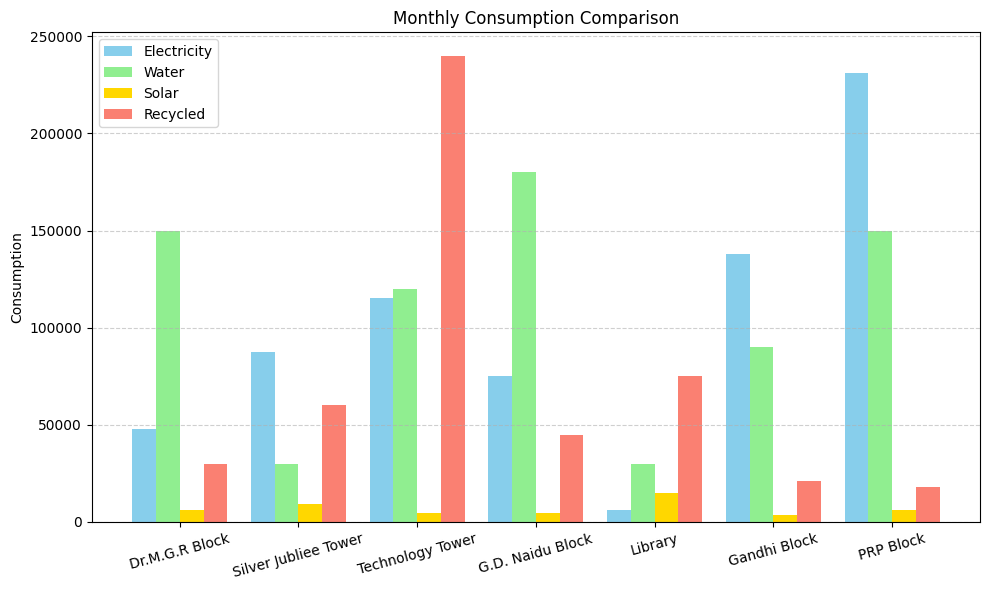

In [ ]:
print("Would you like to see monthly or yearly building-wise comparison charts? (yes/no): ", end="")
choice = input().strip().lower()
if choice in ["yes", "y"]:
   print("Enter 'monthly' or 'yearly': ", end="")
   chart_type = input().strip().lower()
   if chart_type == "monthly":
     show_building_comparison_chart("Monthly", 30)
   elif chart_type == "yearly":
     show_building_comparison_chart("Yearly", 365)
   else:
     print("Invalid option. No comparison chart displayed.")
else:
   print("Thank you. Analysis complete.")